DBSCAN is one of the most powerful clustering algorithms used in real-world machine learning systems when:

- Number of clusters is unknown
- Clusters have irregular shapes
- Dataset contains noise/outliers
- Cluster sizes are not necessarily spherical

Unlike K-Means, DBSCAN does not try to find cluster centers.

Instead, DBSCAN discovers **dense regions of data points** and groups them together.

### Why DBSCAN Was Created
Consider a customer dataset:
| Customer | Income | Spending |
| -------- | ------ | -------- |
| A        | 50k    | 60       |
| B        | 52k    | 62       |
| C        | 53k    | 61       |
| D        | 200k   | 10       |
| E        | 202k   | 12       |
| F        | 900k   | 95       |

Visualzed:

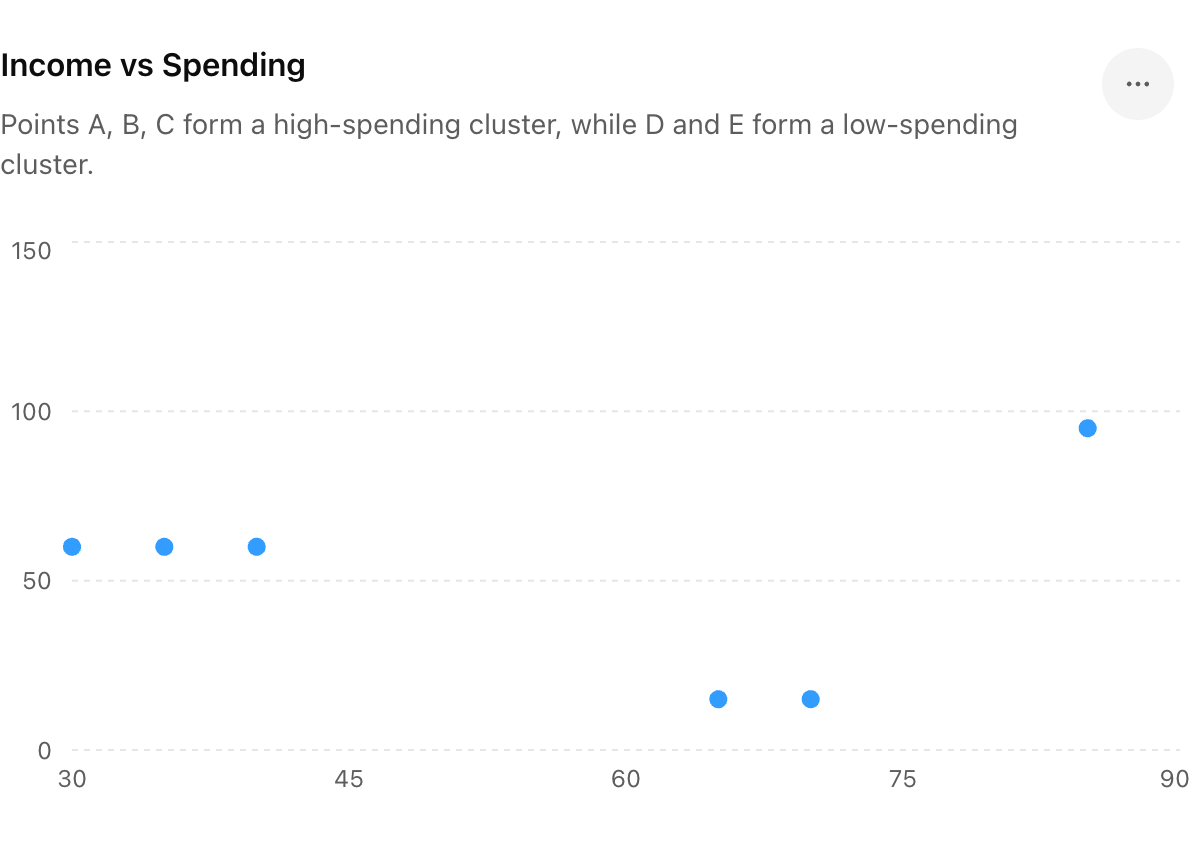


Observations:
- A,B,C form one group
- D,E form another group
- F is isolated

K-Means will force F into a cluster.

DBSCAN identifies:
```
Cluster 1 = {A,B,C}

Cluster 2 = {D,E}

Noise = {F}
```

This ability to detect outliers is one of DBSCAN's biggest advantages.

### Core Idea
DBSCAN assumes:
> Dense areas represent clusters.

> Sparse areas separate clusters.

Instead of calculating centroids:
- Count neighboring points
- Find dense regions
- Expand clusters from those dense regions

### Important Terminology
DBSCAN revolves around two parameters:

#### ε (Epsilon)
Radius around a point.
```
         ●

     ε Radius
```

All points inside this circle are neighbors.

#### MinPts
Minimum number of points required inside ε-radius to form a dense region.

Example:
```
MinPts = 5
```

At least 5 points must exist nearby.

### Three Types of Points
DBSCAN classifies every point into one of three categories.

#### A. Core Point
A point having at least MinPts neighbors within ε.

Example:
```
      ● ● ●
    ● ●C● ●
      ● ●
```

If count ≥ MinPts:
```
C = Core Point
```

#### B. Border Point
Not dense enough to be a core point.

But lies near a core point.
```
     Core Region

   ● ● ● ● ●

          B
```

B belongs to cluster.

But B itself cannot expand cluster.

#### C. Noise Point
Not connected to any cluster.
```
      X
```

Noise point.

Also called:
- Outlier
- Anomaly

### Mathematical Definition
For a point p:

Neighborhood:
$$
N_{\varepsilon}(p) = \{\, q \mid \operatorname{dist}(p,q) \le \varepsilon \,\}
$$

A point becomes Core Point if:
$$
\left| N_{\varepsilon}(p) \right| \ge \text{MinPts}
$$

where:
$$
N_{\varepsilon}(p)
$$

is number of neighboring points.

### Density Reachability
This is the heart of DBSCAN.

Consider:
```
A ---- B ---- C ---- D
```

Suppose:
- A reaches B
- B reaches C
- C reaches D

Then:
```
A reaches D
```

through chain connectivity.

This process allows DBSCAN to discover arbitrary cluster shapes.

### Cluster Expansion Process
Suppose:
```
      ● ● ●
    ● ●A● ●
      ● ●

          ● ●
        ● ● ●
```

#### Step 1:
Choose A.

Check neighbors.

If A is core:
```
Create Cluster 1
```

#### Step 2:
Add all neighboring points.

#### Step 3:
Check every neighbor.

If neighbor is core:
```
Expand further
```

#### Step 4:
Continue until no reachable points remain.

Cluster completed.

### Example Walkthrough
Dataset:
```
P1 P2 P3 P4 P5

          P6 P7 P8

                  P9
```

Parameters:
```
ε = 2

MinPts = 3
```

#### P1
Has enough neighbors.

Core Point.

Create Cluster 1.

#### P2
Reachable from P1.

Add to Cluster 1.

#### P3
Reachable.

Add.

#### P4
Reachable.

Add.

#### P5
Reachable.

Add.

Cluster 1 complete.

#### P6
New dense region.

Create Cluster 2.

#### P7
Add.

#### P8
Add.

Cluster 2 complete.

#### P9
Not enough neighbors.

Noise.

Result:
```
Cluster 1 = {P1,P2,P3,P4,P5}

Cluster 2 = {P6,P7,P8}

Noise = {P9}
```

### Visual Understanding
**K-Means** - Uses circles around centroids.

**DBSCAN** - Can detect arbitrary shapes.

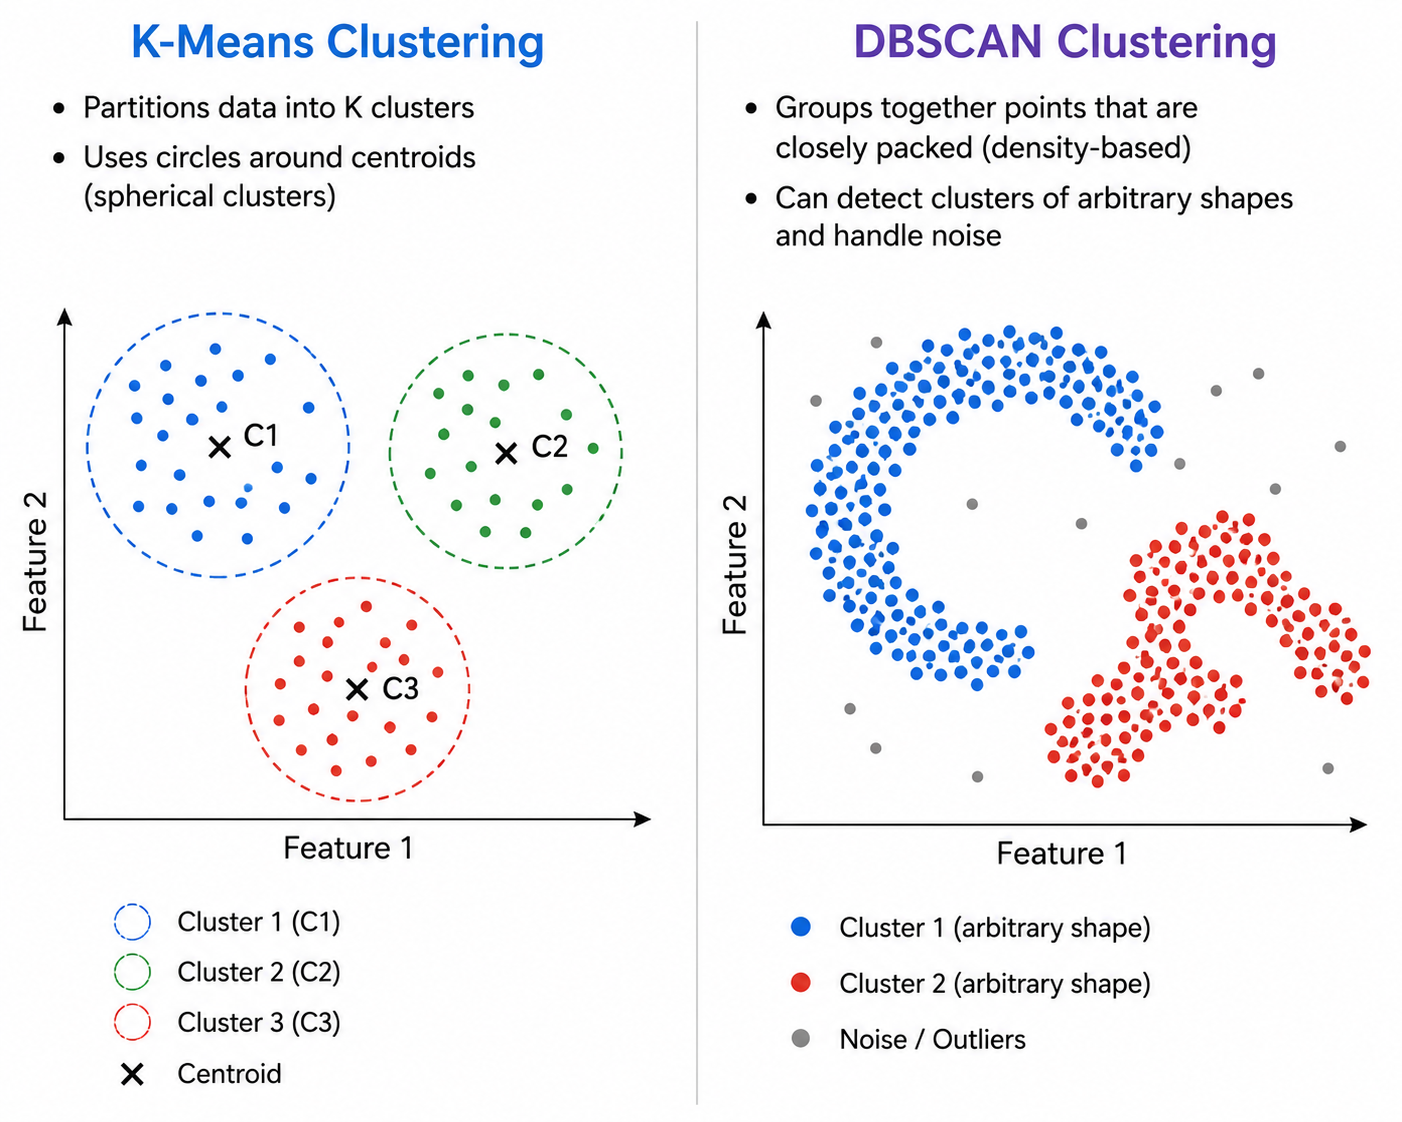

### Algorithm Steps
Input:
```
Dataset D
ε
MinPts
```

#### Step 1
Pick an unvisited point.

#### Step 2
Find ε-neighborhood.

#### Step 3
Check:
```
neighbors >= MinPts ?
```

#### Step 4
If NO:
```
Mark Noise
```

#### Step 5
If YES:
```
Create Cluster
```

#### Step 6
Expand cluster recursively.

#### Step 7
Repeat until all points processed.

### Computational Complexity
Without indexing:
$$
O(n^2)
$$
Every point compared with every point.

Using spatial indexes:
- KD Tree
- Ball Tree
- R Tree

Complexity becomes approximately:
$$
O(nlogn)
$$

### Choosing ε (Epsilon)
Most critical hyperparameter.

Too Small:
```
Many noise points
```

Too Large:
```
Different clusters merge
```

Example:
```
ε = 0.1

Cluster 1
Cluster 2
Cluster 3
Noise
Noise
Noise
```

```
ε = 100

Everything becomes one cluster
```

### Choosing MinPts
Common rule:
$$
MinPts≥Dimension+1
$$
Examples:
| Features | Suggested MinPts |
| -------- | ---------------- |
| 2        | 4                |
| 3        | 5                |
| 10       | 11+              |

Practical values:
```
5–20
```
are common.

### k-Distance Graph
Used for selecting ε.

Procedure:
1. Compute distance to kth nearest neighbor
1. Sort distances
1. Plot graph

Example:

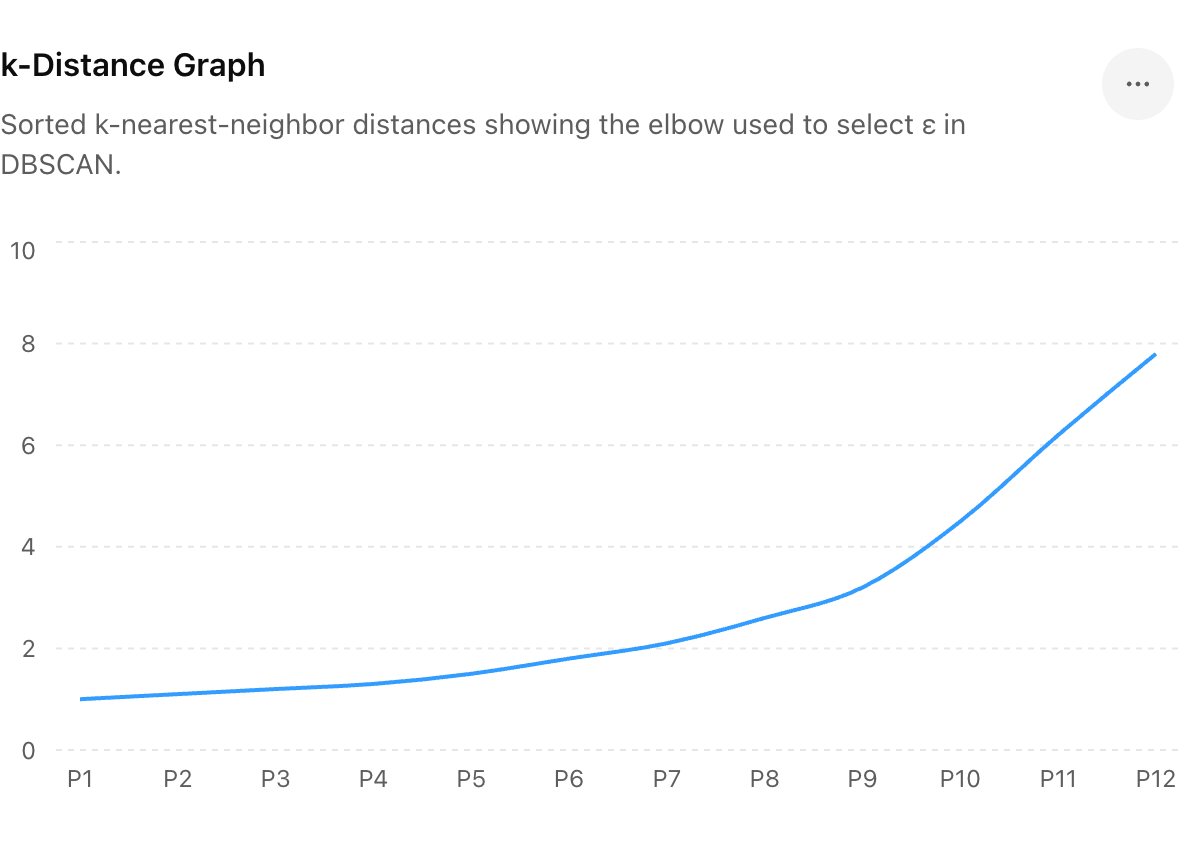

Elbow point:
```
ε ≈ elbow distance
```

### Advantages
#### No Need for K
K-Means:
```
Need K beforehand
```

DBSCAN:
```
No K required
```

#### Detects Noise
Outliers automatically identified.

#### Arbitrary Shapes
Can detect:
```
Moon Shapes
Spirals
Curves
Road Networks
River Patterns
```

#### Robust
Less affected by outliers.

### Disadvantages
#### Sensitive to ε
Wrong ε destroys clustering quality.

#### Variable Density Problem
Example:
```
Dense Cluster

Sparse Cluster
```
One ε cannot fit both.

#### High Dimensions
Distance loses meaning.

Curse of dimensionality reduces effectiveness.

### DBSCAN vs K-Means
| Feature               | K-Means | DBSCAN |
| --------------------- | ------- | ------ |
| Need K                | Yes     | No     |
| Detect Outliers       | No      | Yes    |
| Arbitrary Shapes      | No      | Yes    |
| Speed                 | Faster  | Slower |
| Sensitive to Noise    | High    | Low    |
| Unequal Cluster Sizes | Poor    | Better |

### DBSCAN vs Hierarchical Clustering
| Feature          | Hierarchical | DBSCAN     |
| ---------------- | ------------ | ---------- |
| Dendrogram       | Yes          | No         |
| Noise Detection  | Limited      | Excellent  |
| Scalability      | Lower        | Higher     |
| Arbitrary Shapes | Limited      | Strong     |
| Hyperparameters  | Few          | ε + MinPts |


### Problem Statement

A large digital payments platform processes approximately 15 million transactions per day across multiple channels:

- Mobile Banking
- Internet Banking
- Point-of-Sale (POS)
- Merchant Payments

The platform serves several customer segments:

- Retail Customers
- Premium Customers
- Corporate Customers
- Business Accounts

Every day, a small percentage of transactions exhibit unusual behavior such as:

- Extremely large transaction amounts
- Transactions from unfamiliar locations
- Unusual transaction frequency
- Suspicious merchant categories
- Long periods of inactivity followed by high-value transactions

The challenge is that fraud labels are often unavailable, delayed, or incomplete.

As a result, supervised models cannot always identify newly emerging fraud patterns.

#### Why DBSCAN?
Traditional clustering methods such as K-Means require:
```
Number of clusters (K)
```
to be specified beforehand.

In real banking environments:
```
Number of behavioral groups is unknown
```
and new customer segments may emerge over time.

DBSCAN is preferred because it:
- Automatically discovers cluster count
- Detects outliers directly
- Handles irregular cluster shapes
- Works well for anomaly detection
- Requires no fraud labels

In [1]:
import pandas as pd
import joblib

from sklearn.cluster import DBSCAN
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [3]:
df = pd.read_csv("./data/transactions_dataset.csv")

In [4]:
features = [
    "Amount",
    "Time_Gap_Minutes",
    "Customer_Age",
    "Transactions_Per_Day",
    "Channel",
    "Merchant_Category",
    "Location"
]

X = df[features]

In [5]:
numerical_cols = [
    "Amount",
    "Time_Gap_Minutes",
    "Customer_Age",
    "Transactions_Per_Day"
]

categorical_cols = [
    "Channel",
    "Merchant_Category",
    "Location"
]

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ]
)

In [7]:
X_processed = preprocessor.fit_transform(X)

In [8]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=20,
    metric="euclidean"
)

clusters = dbscan.fit_predict(X_processed)

In [9]:
df["Cluster"] = clusters

In [10]:
print("\nCluster Distribution\n")
print(df["Cluster"].value_counts())

print("\nNoise Points\n")
print((df["Cluster"] == -1).sum())


Cluster Distribution

Cluster
 0    7796
-1     204
Name: count, dtype: int64

Noise Points

204


In [11]:
import os
import joblib

os.makedirs("project-dbscan", exist_ok=True)


joblib.dump(
    preprocessor,
    "project-dbscan/dbscan_preprocessor.pkl"
)

joblib.dump(
    dbscan,
    "project-dbscan/dbscan_model.pkl"
)


df.to_csv(
    "project-dbscan/clustered_transactions.csv",
    index=False
)

print("\nTraining Complete")
print("Artifacts saved successfully.")


Training Complete
Artifacts saved successfully.


In [12]:
cluster_summary = (
    df.groupby("Cluster")
      .agg({
          "Amount": "mean",
          "Time_Gap_Minutes": "mean",
          "Customer_Age": "mean",
          "Transactions_Per_Day": "mean"
      })
)

print(cluster_summary)

                Amount  Time_Gap_Minutes  Customer_Age  Transactions_Per_Day
Cluster                                                                     
-1       296355.892990        770.716029     48.887255              2.416667
 0         8089.513466         15.509320     41.047589              7.060800


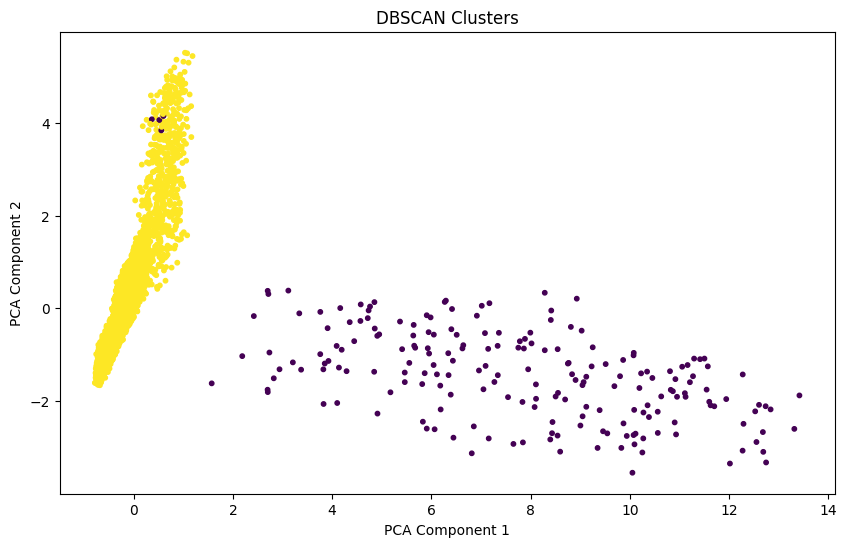

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_processed.toarray())

plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["Cluster"],
    s=10
)

plt.title("DBSCAN Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()